# Kenya Food Price Classification
## XGBoost vs Random Forest

### Objective
The objective of this analysis is to develop and compare two machine learning
classification models, Random Forest and XGBoost, for predicting food price
categories in Kenya.

The target variable is `price_label`, which classifies observations into:
- Cheap
- Average
- Expensive

The models will be evaluated using accuracy, precision, recall, F1-score,
and a confusion matrix, with particular attention to macro F1-score because
the target classes are not perfectly balanced.

In [2]:
import pandas as pd
import numpy as np

# Load the classification dataset
df = pd.read_csv('../../data/cleaned/bei_smart_classification.csv')

# Display the first 5 rows
df.head()

,date,region,county,market,market_id,latitude,longitude,category,commodity,commodity_id,...,month,year,season,petrol_price_kes,diesel_price_kes,rolling_3m_avg,rolling_6m_avg,rolling_12m_avg,price_vs_regional_avg,price_label
0,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,pulses and nuts,Beans,50,...,9,2024,Dry Season,188.84,171.60,160.000000,160.000000,160.000000,1.050687,Average
1,2024-03-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,3,2024,Long Rains,206.36,196.47,200.000000,200.000000,200.000000,1.097394,Average
2,2024-06-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,6,2024,Dry Season,189.84,179.30,200.000000,200.000000,200.000000,1.201201,Expensive
3,2024-09-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,9,2024,Dry Season,188.84,171.60,196.666667,196.666667,196.666667,1.143326,Expensive
4,2023-12-15,Rift Valley,Turkana,Alemsekon,10457,3.53,34.82,pulses and nuts,Beans,50,...,12,2023,Short Rains,212.36,201.47,155.000000,155.000000,155.000000,0.888363,Cheap


In [3]:
# Check dataset shape
print("Shape:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns.tolist())

Shape: (16163, 29)

Columns:
['date', 'region', 'county', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice', 'date_month', 'rainfall_mm', 'price_per_kg', 'month', 'year', 'season', 'petrol_price_kes', 'diesel_price_kes', 'rolling_3m_avg', 'rolling_6m_avg', 'rolling_12m_avg', 'price_vs_regional_avg', 'price_label']


In [4]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16163 entries, 0 to 16162
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   16163 non-null  str    
 1   region                 16163 non-null  str    
 2   county                 16163 non-null  str    
 3   market                 16163 non-null  str    
 4   market_id              16163 non-null  int64  
 5   latitude               16163 non-null  float64
 6   longitude              16163 non-null  float64
 7   category               16163 non-null  str    
 8   commodity              16163 non-null  str    
 9   commodity_id           16163 non-null  int64  
 10  unit                   16163 non-null  str    
 11  priceflag              16163 non-null  str    
 12  pricetype              16163 non-null  str    
 13  currency               16163 non-null  str    
 14  price                  16163 non-null  float64
 15  usdprice     

In [5]:
# Target variable distribution
print(df['price_label'].value_counts())

print("\nPercentage distribution:")
print(df['price_label'].value_counts(normalize=True).mul(100).round(2))

price_label
Average      10804
Cheap         2831
Expensive     2528
Name: count, dtype: int64

Percentage distribution:
price_label
Average      66.84
Cheap        17.52
Expensive    15.64
Name: proportion, dtype: float64


In [6]:
# Display all columns with their data types
pd.set_option('display.max_rows', None)

column_info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Unique Values': df.nunique()
})

column_info

,Column,Data Type,Unique Values
date,date,str,120
region,region,str,5
county,county,str,19
market,market,str,205
market_id,market_id,int64,205
latitude,latitude,float64,165
longitude,longitude,float64,172
category,category,str,7
commodity,commodity,str,31
commodity_id,commodity_id,int64,31


In [7]:
# Check the actual values in the target variable
df['price_label'].unique()

<ArrowStringArray>
['Average', 'Expensive', 'Cheap']
Length: 3, dtype: str

In [8]:
# Check whether there are duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 2. Feature Selection and Leakage Prevention

The classification dataset contains information about food prices, markets,
commodities, weather, seasonality, and fuel prices.

To avoid data leakage and highly redundant predictors, the following variables
are excluded from model training:

- `price` — direct price measure used to construct the classification target
- `price_per_kg` — normalized price measure directly related to the target
- `usdprice` — alternative representation of price
- `petrol_price_kes` — highly correlated/redundant with other economic variables
- `rolling_3m_avg` — highly correlated with other rolling price features
- `rolling_6m_avg` — highly correlated with other rolling price features
- `price_label` — target variable, not a predictor
- `date` and `date_month` — raw date strings; temporal information is already
  represented by `month`, `year`, and `season`

The model will retain location, commodity, seasonal, rainfall, fuel, and
historical-price-context features that were identified during the EDA.

In [9]:
# Define features and target

drop_columns = [
    'price',
    'price_per_kg',
    'usdprice',
    'petrol_price_kes',
    'rolling_3m_avg',
    'rolling_6m_avg',
    'price_label',
    'date',
    'date_month'
]

X = df.drop(columns=drop_columns)
y = df['price_label']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature matrix shape: (16163, 20)
Target shape: (16163,)

Features:
['region', 'county', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'rainfall_mm', 'month', 'year', 'season', 'diesel_price_kes', 'rolling_12m_avg', 'price_vs_regional_avg']


In [10]:
# Separate categorical and numerical features

categorical_features = X.select_dtypes(include=['str', 'object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['region', 'county', 'market', 'category', 'commodity', 'unit', 'priceflag', 'pricetype', 'currency', 'season']

Numerical features:
['market_id', 'latitude', 'longitude', 'commodity_id', 'rainfall_mm', 'month', 'year', 'diesel_price_kes', 'rolling_12m_avg', 'price_vs_regional_avg']


## 3. Train-Test Split

The dataset will be divided into training and testing sets using an 80/20 split.

Stratified sampling will be used to preserve the proportion of Cheap, Average,
and Expensive observations in both sets. This is important because the target
classes are imbalanced.

In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (12930, 20)
Testing set: (3233, 20)

Training target distribution:
price_label
Average      0.668
Cheap        0.175
Expensive    0.156
Name: proportion, dtype: float64

Testing target distribution:
price_label
Average      0.668
Cheap        0.175
Expensive    0.157
Name: proportion, dtype: float64


## 4. Data Preprocessing

Categorical variables will be converted into numerical representations using
One-Hot Encoding. Numerical variables will be passed through without scaling
because Random Forest and XGBoost are tree-based algorithms and do not require
feature scaling.

The preprocessing will be placed inside a pipeline to ensure that preprocessing
is learned only from the training data and to reduce the risk of data leakage.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing for categorical variables
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Combine categorical and numerical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 5. Random Forest Classification

Random Forest is an ensemble learning algorithm that combines multiple
decision trees. Each tree is trained using different samples and feature
subsets, and their predictions are combined to produce the final class.

Random Forest is used as the first baseline model so that its performance
can later be compared with XGBoost using the same training and testing data.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [14]:
# Train Random Forest
rf_pipeline.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [15]:
# Predict on the test set
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest predictions completed.")
print(y_pred_rf[:10])

Random Forest predictions completed.
['Cheap' 'Average' 'Average' 'Expensive' 'Average' 'Cheap' 'Average'
 'Average' 'Average' 'Cheap']


## 6. Random Forest Evaluation

The Random Forest model is evaluated using accuracy, precision, recall,
and F1-score. Because the target classes are imbalanced, macro-averaged
metrics are particularly important.

A confusion matrix is also used to identify which price categories are
being confused by the model.

In [16]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

# Detailed classification report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9895

Random Forest Classification Report:
              precision    recall  f1-score   support

     Average       0.99      1.00      0.99      2161
       Cheap       0.99      0.97      0.98       566
   Expensive       0.99      0.98      0.99       506

    accuracy                           0.99      3233
   macro avg       0.99      0.98      0.99      3233
weighted avg       0.99      0.99      0.99      3233



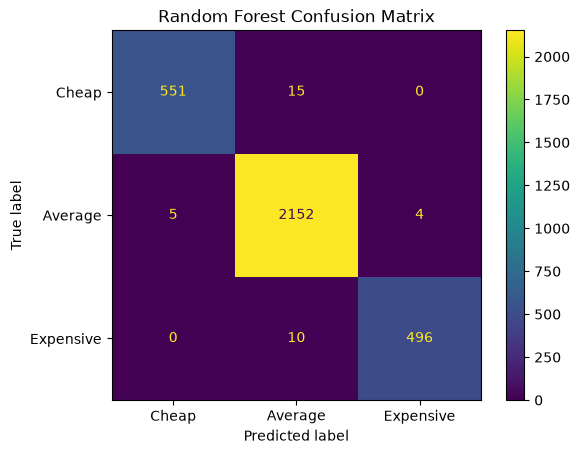

In [17]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=['Cheap', 'Average', 'Expensive']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Cheap', 'Average', 'Expensive']
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [18]:
# Check the relationship between price-related features and the target
df.groupby('price_label')[
    ['rolling_12m_avg', 'price_vs_regional_avg']
].agg(['mean', 'median', 'min', 'max'])

rolling_12m_avg                                    \
                       mean     median        min         max   
price_label                                                     
Average          161.801046  115.61250  30.580000  815.943333   
Cheap            113.070466   92.00000  27.500000  694.907500   
Expensive        154.824556  131.21625  39.516667  742.256667   

            price_vs_regional_avg                                
                             mean    median       min       max  
price_label                                                      
Average                  0.997736  1.000000  0.900017  1.100000  
Cheap                    0.797239  0.828358  0.266809  0.900000  
Expensive                1.236737  1.182752  1.100141  3.712172

In [19]:
# Compare price-related variables across the three classes
df.groupby('price_label')[
    ['price', 'price_per_kg', 'rolling_12m_avg', 'price_vs_regional_avg']
].mean()

,price,price_per_kg,rolling_12m_avg,price_vs_regional_avg
price_label,,,,
Average,158.328888,164.604687,161.801046,0.997736
Cheap,96.739968,103.567294,113.070466,0.797239
Expensive,154.643196,164.944529,154.824556,1.236737


## 7. Leakage-Safe Random Forest Check

The exploratory analysis showed that `price_vs_regional_avg` has very strong
separation between the three target classes. Since this feature is derived
from price information, we test a second Random Forest model without it.

This provides a more conservative estimate of model performance and helps
determine whether the very high baseline performance is dependent on a
price-derived feature.

In [20]:
# Remove the potentially leakage-prone feature
X_safe = X.drop(columns=['price_vs_regional_avg'])

# Identify categorical and numerical features again
categorical_features_safe = X_safe.select_dtypes(
    include=['str', 'object']
).columns.tolist()

numerical_features_safe = X_safe.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Leakage-safe feature count:", X_safe.shape[1])
print("\nCategorical features:")
print(categorical_features_safe)

print("\nNumerical features:")
print(numerical_features_safe)

Leakage-safe feature count: 19

Categorical features:
['region', 'county', 'market', 'category', 'commodity', 'unit', 'priceflag', 'pricetype', 'currency', 'season']

Numerical features:
['market_id', 'latitude', 'longitude', 'commodity_id', 'rainfall_mm', 'month', 'year', 'diesel_price_kes', 'rolling_12m_avg']


In [21]:
X_train_safe, X_test_safe, y_train_safe, y_test_safe = train_test_split(
    X_safe,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train_safe.shape)
print("Testing set:", X_test_safe.shape)

Training set: (12930, 19)
Testing set: (3233, 19)


In [22]:
#create a new preprocessor without the leakage-prone feature
preprocessor_safe = ColumnTransformer(
    transformers=[
        ('cat',
         OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features_safe),

        ('num',
         'passthrough',
         numerical_features_safe)
    ]
)

In [23]:
# Create and train a leakage-safe Random Forest pipeline
rf_safe_pipeline = Pipeline([
    ('preprocessor', preprocessor_safe),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_safe_pipeline.fit(X_train_safe, y_train_safe)

y_pred_rf_safe = rf_safe_pipeline.predict(X_test_safe)

print("Leakage-safe Random Forest training completed.")

Leakage-safe Random Forest training completed.


In [24]:
#evaluate the leakage-safe Random Forest model
rf_safe_accuracy = accuracy_score(y_test_safe, y_pred_rf_safe)

print(f"Leakage-safe Random Forest Accuracy: {rf_safe_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_safe, y_pred_rf_safe))

Leakage-safe Random Forest Accuracy: 0.7433

Classification Report:
              precision    recall  f1-score   support

     Average       0.86      0.79      0.82      2161
       Cheap       0.57      0.66      0.61       566
   Expensive       0.54      0.64      0.59       506

    accuracy                           0.74      3233
   macro avg       0.66      0.70      0.67      3233
weighted avg       0.76      0.74      0.75      3233



## 8. XGBoost Classification

XGBoost (Extreme Gradient Boosting) is an ensemble learning algorithm that
builds decision trees sequentially. Each new tree attempts to correct errors
made by the previous trees.

XGBoost is trained using the same leakage-safe features and train-test split
used for Random Forest, allowing a fair comparison between the two models.

In [25]:
from xgboost import XGBClassifier

2. Encode the target

XGBoost needs the target classes represented numerically.

In [26]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train_safe)
y_test_encoded = label_encoder.transform(y_test_safe)

print("Class mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} -> {i}")

Class mapping:
Average -> 0
Cheap -> 1
Expensive -> 2


3. Build the XGBoost pipeline

In [27]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_safe),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


4. Train XGBoost

In [28]:
xgb_pipeline.fit(
    X_train_safe,
    y_train_encoded
)

print("XGBoost training completed.")

XGBoost training completed.


5. Predict

In [29]:
y_pred_xgb_encoded = xgb_pipeline.predict(X_test_safe)

print("XGBoost predictions completed.")
print(y_pred_xgb_encoded[:10])

XGBoost predictions completed.
[1 0 0 2 0 1 0 0 0 1]


In [30]:
# Convert the encoded XGBoost predictions back to the original class labels
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

print(y_pred_xgb[:10])

['Cheap' 'Average' 'Average' 'Expensive' 'Average' 'Cheap' 'Average'
 'Average' 'Average' 'Cheap']


In [31]:
#evaluate the XGBoost 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBoost accuracy
xgb_accuracy = accuracy_score(y_test_encoded, y_pred_xgb_encoded)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(f"XGBoost Accuracy: {xgb_accuracy * 100:.2f}%")

XGBoost Accuracy: 0.7742
XGBoost Accuracy: 77.42%


In [32]:
print("XGBoost Classification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_xgb_encoded,
    target_names=label_encoder.classes_
))

XGBoost Classification Report:
              precision    recall  f1-score   support

     Average       0.79      0.92      0.85      2161
       Cheap       0.70      0.50      0.58       566
   Expensive       0.74      0.47      0.58       506

    accuracy                           0.77      3233
   macro avg       0.74      0.63      0.67      3233
weighted avg       0.77      0.77      0.76      3233



In [33]:
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb_encoded)

print("XGBoost Confusion Matrix:")
print(cm_xgb)

XGBoost Confusion Matrix:
[[1983  106   72]
 [ 273  281   12]
 [ 251   16  239]]


coompare models probely

In [34]:
from sklearn.metrics import f1_score

# Calculate F1 scores
rf_macro_f1 = f1_score(
    y_test_safe,
    y_pred_rf_safe,
    average='macro'
)

rf_weighted_f1 = f1_score(
    y_test_safe,
    y_pred_rf_safe,
    average='weighted'
)

xgb_macro_f1 = f1_score(
    y_test_encoded,
    y_pred_xgb_encoded,
    average='macro'
)

xgb_weighted_f1 = f1_score(
    y_test_encoded,
    y_pred_xgb_encoded,
    average='weighted'
)

# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy, xgb_accuracy],
    'Macro F1': [rf_macro_f1, xgb_macro_f1],
    'Weighted F1': [rf_weighted_f1, xgb_weighted_f1]
})

comparison

,Model,Accuracy,Macro F1,Weighted F1
0,Random Forest,0.989483,0.674725,0.749551
1,XGBoost,0.774204,0.668731,0.759679


In [35]:
rf_accuracy_safe = accuracy_score(y_test_safe, y_pred_rf_safe)

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy_safe, xgb_accuracy],
    'Macro F1': [rf_macro_f1, xgb_macro_f1],
    'Weighted F1': [rf_weighted_f1, xgb_weighted_f1]
})

comparison

,Model,Accuracy,Macro F1,Weighted F1
0,Random Forest,0.743273,0.674725,0.749551
1,XGBoost,0.774204,0.668731,0.759679


XGBoost achieved the best overall predictive performance with 77.42% accuracy and a weighted F1-score of 0.760. Random Forest achieved 74.33% accuracy and a weighted F1-score of 0.750. Although Random Forest had a slightly higher macro F1-score, XGBoost provided better overall performance.

In [36]:
# Get feature names after one-hot encoding
feature_names = rf_safe_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get Random Forest feature importance
rf_importance = rf_safe_pipeline.named_steps['classifier'].feature_importances_

# Create feature importance DataFrame
rf_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance
}).sort_values(by='Importance', ascending=False)

rf_feature_importance.head(15)

,Feature,Importance
287,num__rolling_12m_avg,0.161074
283,num__rainfall_mm,0.068584
286,num__diesel_price_kes,0.060463
279,num__market_id,0.058491
281,num__longitude,0.054426
280,num__latitude,0.053033
284,num__month,0.048364
285,num__year,0.042016
282,num__commodity_id,0.037503
276,cat__season_Dry Season,0.015012


In [37]:
# Get feature names after one-hot encoding
xgb_feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get XGBoost feature importance
xgb_importance = xgb_pipeline.named_steps['classifier'].feature_importances_

# Create feature importance DataFrame
xgb_feature_importance = pd.DataFrame({
    'Feature': xgb_feature_names,
    'Importance': xgb_importance
}).sort_values(by='Importance', ascending=False)

xgb_feature_importance.head(15)

,Feature,Importance
272,cat__priceflag_aggregate,0.071027
271,cat__priceflag_actual,0.057286
18,cat__county_Nairobi,0.015954
2,cat__region_Nairobi,0.012910
265,cat__commodity_Wheat flour,0.011426
135,cat__market_Lodwar (Turkana),0.011272
65,cat__market_Garissa,0.010878
168,cat__market_Marigat (Baringo),0.010570
19,cat__county_Samburu,0.009297
85,cat__market_Kajiado,0.009140


In [38]:
df.groupby('priceflag')['price_label'].value_counts(normalize=True)

priceflag  price_label
actual     Average        0.525328
           Cheap          0.251050
           Expensive      0.223622
aggregate  Average        0.796090
           Cheap          0.107456
           Expensive      0.096453
Name: proportion, dtype: float64

In [39]:
df.groupby('priceflag')['price_label'].value_counts()

priceflag  price_label
actual     Average        4003
           Cheap          1913
           Expensive      1704
aggregate  Average        6801
           Cheap           918
           Expensive       824
Name: count, dtype: int64

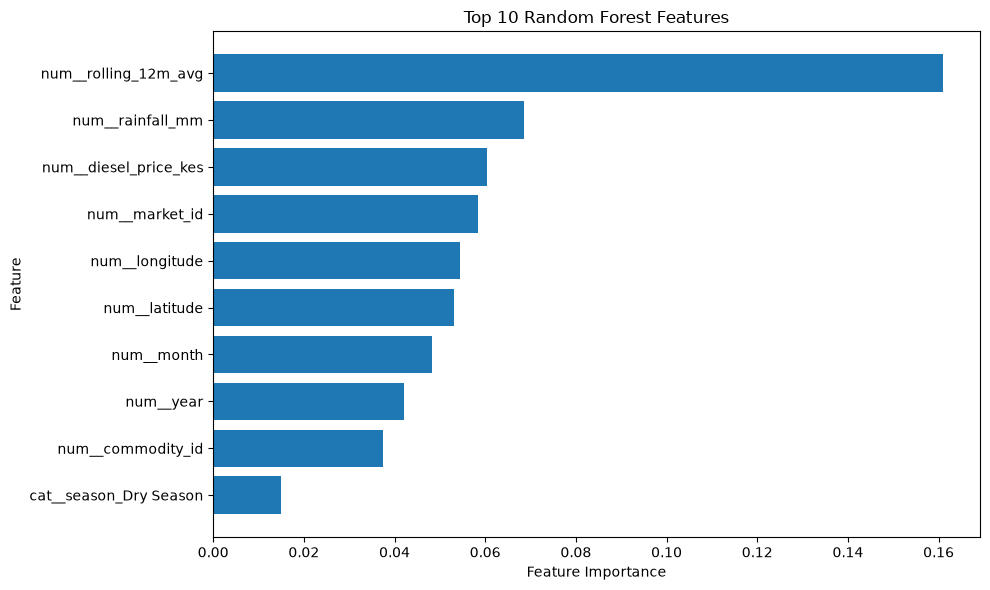

In [40]:
import matplotlib.pyplot as plt

top_rf = rf_feature_importance.head(10).sort_values('Importance')

plt.figure(figsize=(10, 6))
plt.barh(top_rf['Feature'], top_rf['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Random Forest Features')
plt.tight_layout()
plt.show()

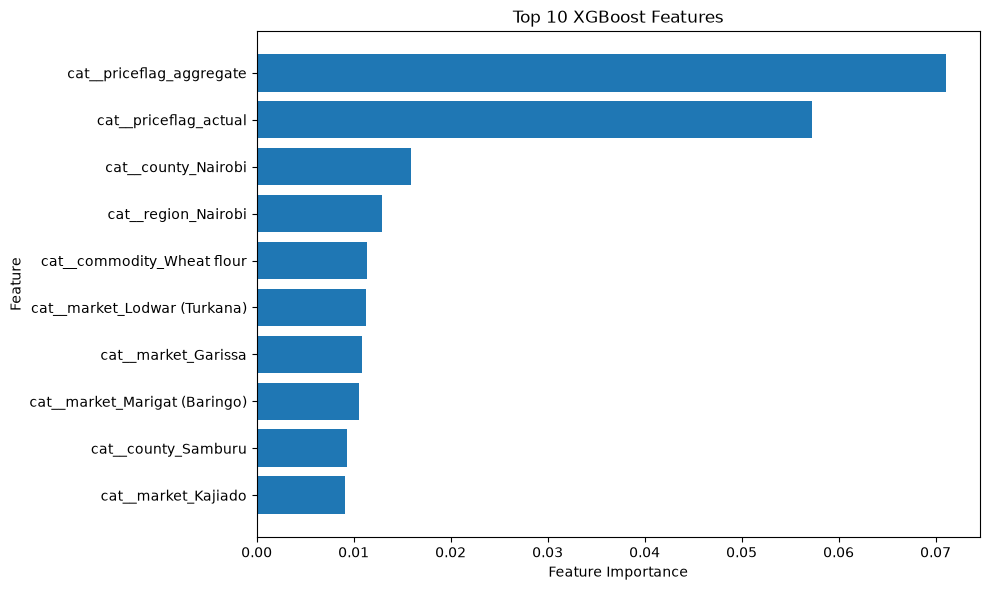

In [41]:
# XGBoost Top 10 Feature Importance

top_xgb = xgb_feature_importance.head(10).sort_values('Importance')

plt.figure(figsize=(10, 6))
plt.barh(top_xgb['Feature'], top_xgb['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 XGBoost Features')
plt.tight_layout()
plt.show()

In [42]:
df[['date', 'market', 'commodity', 'price', 'rolling_12m_avg']].head(20)

,date,market,commodity,price,rolling_12m_avg
0,2024-09-15,Adele Center,Beans,160.0,160.000000
1,2024-03-15,Alango Arba,Beans,200.0,200.000000
2,2024-06-15,Alango Arba,Beans,200.0,200.000000
3,2024-09-15,Alango Arba,Beans,190.0,196.666667
4,2023-12-15,Alemsekon,Beans,155.0,155.000000
5,2024-03-15,Alemsekon,Beans,203.0,179.000000
6,2024-06-15,Alemsekon,Beans,188.0,182.000000
7,2024-09-15,Alemsekon,Beans,164.0,177.500000
8,2024-03-15,Alinjugur,Beans,194.0,194.000000
9,2024-06-15,Alinjugur,Beans,192.0,193.000000


In [43]:
#create the final leakage safe dataset by dropping the leakage-prone feature
X_final = X.drop(columns=['rolling_12m_avg'])

categorical_features_final = X_final.select_dtypes(
    include=['str', 'object']
).columns.tolist()

numerical_features_final = X_final.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Final number of features:", X_final.shape[1])
print("\nCategorical features:")
print(categorical_features_final)

print("\nNumerical features:")
print(numerical_features_final)

Final number of features: 19

Categorical features:
['region', 'county', 'market', 'category', 'commodity', 'unit', 'priceflag', 'pricetype', 'currency', 'season']

Numerical features:
['market_id', 'latitude', 'longitude', 'commodity_id', 'rainfall_mm', 'month', 'year', 'diesel_price_kes', 'price_vs_regional_avg']


In [44]:
X_final = X.drop(columns=[
    'rolling_12m_avg',
    'price_vs_regional_avg'
])

categorical_features_final = X_final.select_dtypes(
    include=['str', 'object']
).columns.tolist()

numerical_features_final = X_final.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Final number of features:", X_final.shape[1])

print("\nCategorical features:")
print(categorical_features_final)

print("\nNumerical features:")
print(numerical_features_final)

Final number of features: 18

Categorical features:
['region', 'county', 'market', 'category', 'commodity', 'unit', 'priceflag', 'pricetype', 'currency', 'season']

Numerical features:
['market_id', 'latitude', 'longitude', 'commodity_id', 'rainfall_mm', 'month', 'year', 'diesel_price_kes']


In [45]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train_final.shape)
print("Test set:", X_test_final.shape)

Training set: (12930, 18)
Test set: (3233, 18)


In [46]:
preprocessor_final = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features_final
        ),
        (
            'num',
            'passthrough',
            numerical_features_final
        )
    ]
)

print("Final preprocessing pipeline created successfully.")

Final preprocessing pipeline created successfully.


In [47]:
rf_final_pipeline = Pipeline([
    ('preprocessor', preprocessor_final),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_final_pipeline.fit(X_train_final, y_train_final)

y_pred_rf_final = rf_final_pipeline.predict(X_test_final)

print("Final Random Forest training and prediction completed.")

Final Random Forest training and prediction completed.


In [48]:
rf_final_accuracy = accuracy_score(
    y_test_final,
    y_pred_rf_final
)

print(f"Final Random Forest Accuracy: {rf_final_accuracy:.4f}")
print(f"Final Random Forest Accuracy: {rf_final_accuracy * 100:.2f}%")

Final Random Forest Accuracy: 0.7117
Final Random Forest Accuracy: 71.17%


In [49]:
print("Final Random Forest Classification Report:")
print(classification_report(
    y_test_final,
    y_pred_rf_final
))

Final Random Forest Classification Report:
              precision    recall  f1-score   support

     Average       0.85      0.77      0.81      2161
       Cheap       0.50      0.59      0.54       566
   Expensive       0.49      0.60      0.54       506

    accuracy                           0.71      3233
   macro avg       0.62      0.65      0.63      3233
weighted avg       0.74      0.71      0.72      3233



In [50]:
cm_rf_final = confusion_matrix(
    y_test_final,
    y_pred_rf_final
)

print("Final Random Forest Confusion Matrix:")
print(cm_rf_final)

Final Random Forest Confusion Matrix:
[[1662  258  241]
 [ 153  334   79]
 [ 131   70  305]]


In [51]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Encode target labels
label_encoder_final = LabelEncoder()

y_train_final_encoded = label_encoder_final.fit_transform(y_train_final)
y_test_final_encoded = label_encoder_final.transform(y_test_final)

print("Class mapping:")
for label, code in zip(
    label_encoder_final.classes_,
    label_encoder_final.transform(label_encoder_final.classes_)
):
    print(f"{label} -> {code}")

Class mapping:
Average -> 0
Cheap -> 1
Expensive -> 2


In [52]:
xgb_final_pipeline = Pipeline([
    ('preprocessor', preprocessor_final),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Train XGBoost
xgb_final_pipeline.fit(
    X_train_final,
    y_train_final_encoded
)

# Make predictions
y_pred_xgb_encoded = xgb_final_pipeline.predict(X_test_final)

# Convert predictions back to original labels
y_pred_xgb_final = label_encoder_final.inverse_transform(
    y_pred_xgb_encoded.astype(int)
)

print("Final XGBoost training and prediction completed successfully.")

Final XGBoost training and prediction completed successfully.


In [53]:
from sklearn.metrics import accuracy_score

xgb_final_accuracy = accuracy_score(
    y_test_final,
    y_pred_xgb_final
)

print(f"Final XGBoost Accuracy: {xgb_final_accuracy:.4f}")
print(f"Final XGBoost Accuracy: {xgb_final_accuracy * 100:.2f}%")

Final XGBoost Accuracy: 0.7321
Final XGBoost Accuracy: 73.21%


In [54]:
from sklearn.metrics import classification_report

print("Final XGBoost Classification Report:")
print(classification_report(
    y_test_final,
    y_pred_xgb_final
))

Final XGBoost Classification Report:
              precision    recall  f1-score   support

     Average       0.76      0.93      0.84      2161
       Cheap       0.57      0.36      0.44       566
   Expensive       0.63      0.33      0.43       506

    accuracy                           0.73      3233
   macro avg       0.66      0.54      0.57      3233
weighted avg       0.71      0.73      0.70      3233



In [55]:
from sklearn.metrics import confusion_matrix

cm_xgb_final = confusion_matrix(
    y_test_final,
    y_pred_xgb_final
)

print("Final XGBoost Confusion Matrix:")
print(cm_xgb_final)

Final XGBoost Confusion Matrix:
[[1999   97   65]
 [ 333  201   32]
 [ 286   53  167]]


Random Forest was selected as the preferred classification model because it provided more balanced performance across Cheap, Average, and Expensive price categories. Although XGBoost achieved slightly higher accuracy (73.21%), Random Forest achieved a higher macro F1-score (0.63 vs 0.57), indicating better performance across all classes.

In [57]:
from sklearn.metrics import accuracy_score, f1_score

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test_final, y_pred_rf_final),
        accuracy_score(y_test_final, y_pred_xgb_final)
    ],
    'Macro F1': [
        f1_score(y_test_final, y_pred_rf_final, average='macro'),
        f1_score(y_test_final, y_pred_xgb_final, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test_final, y_pred_rf_final, average='weighted'),
        f1_score(y_test_final, y_pred_xgb_final, average='weighted')
    ]
})

comparison

,Model,Accuracy,Macro F1,Weighted F1
0,Random Forest,0.711723,0.630890,0.720632
1,XGBoost,0.732137,0.569576,0.703821


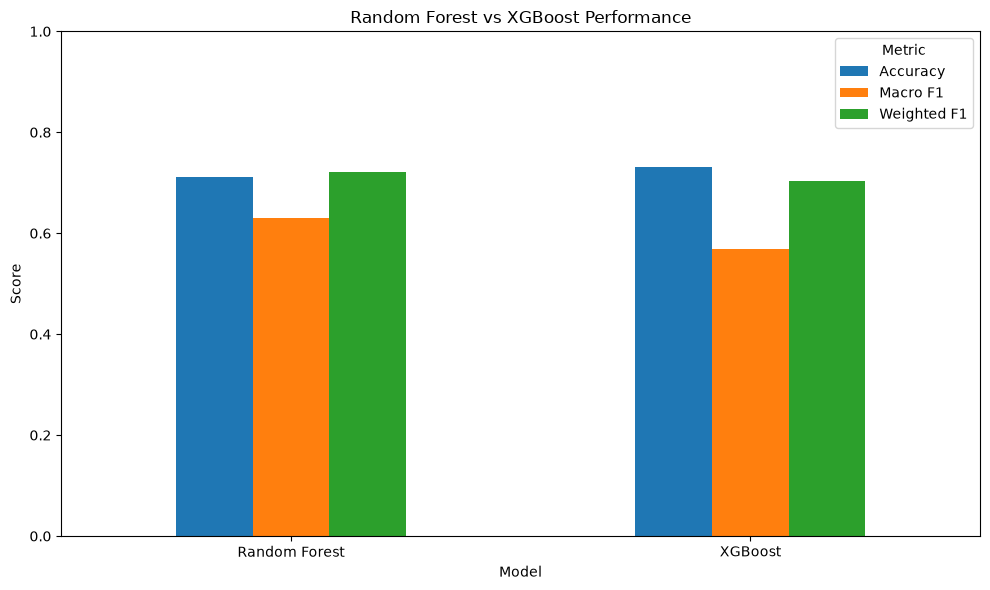

In [58]:
import matplotlib.pyplot as plt

comparison_plot = comparison.set_index('Model')

comparison_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Random Forest vs XGBoost Performance')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

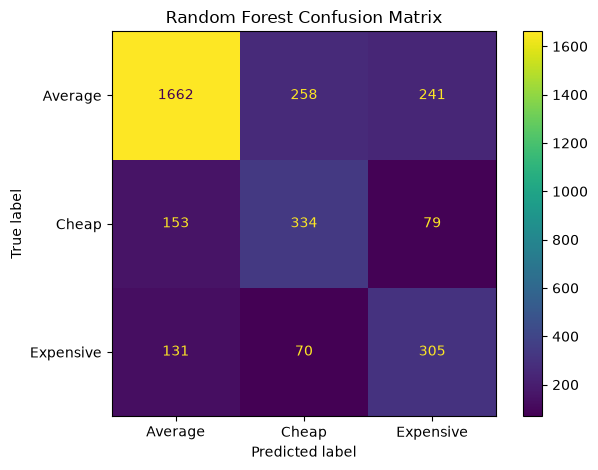

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_final,
    display_labels=['Average', 'Cheap', 'Expensive']
).plot()

plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

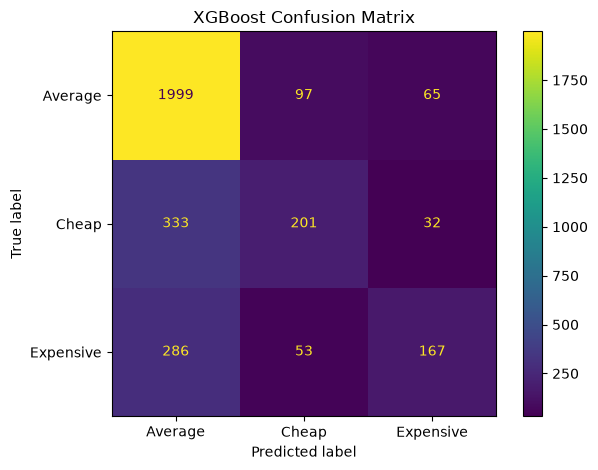

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb_final,
    display_labels=['Average', 'Cheap', 'Expensive']
).plot()

plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.show()

In [61]:
# Get feature names after preprocessing
feature_names_rf = rf_final_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get feature importance
rf_importance = rf_final_pipeline.named_steps[
    'classifier'
].feature_importances_

# Create feature importance dataframe
rf_feature_importance = pd.DataFrame({
    'Feature': feature_names_rf,
    'Importance': rf_importance
})

# Sort from highest to lowest
rf_feature_importance = rf_feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 15
rf_feature_importance.head(15)

,Feature,Importance
283,num__rainfall_mm,0.085995
286,num__diesel_price_kes,0.075217
279,num__market_id,0.070025
281,num__longitude,0.065724
280,num__latitude,0.065376
284,num__month,0.059410
285,num__year,0.052295
282,num__commodity_id,0.045981
276,cat__season_Dry Season,0.017033
277,cat__season_Long Rains,0.015651


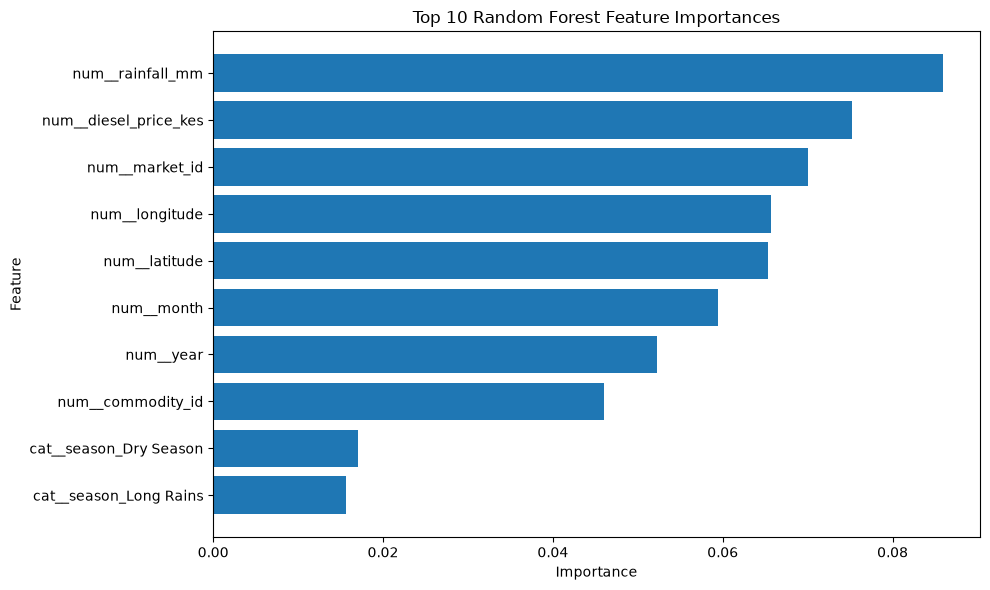

In [62]:
top_rf_features = rf_feature_importance.head(10).sort_values(
    by='Importance'
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rf_features['Feature'],
    top_rf_features['Importance']
)

plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Final Model Results and Selection

Two ensemble classification models were evaluated using the same leakage-safe feature set and train-test split: Random Forest and XGBoost.

### Model Performance

| Model | Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|
| Random Forest | 71.17% | 0.63 | 0.72 |
| XGBoost | 73.21% | 0.57 | 0.70 |

XGBoost achieved a slightly higher overall accuracy of 73.21%, compared with 71.17% for Random Forest. However, Random Forest achieved a higher Macro F1-score (0.63 vs. 0.57), indicating more balanced performance across the Cheap, Average, and Expensive classes.

### Model Selection

Random Forest was selected as the preferred classification model because it provides more balanced classification performance across all three price categories. In particular, it performs better than XGBoost on the minority classes, Cheap and Expensive.

Although XGBoost achieves higher accuracy, its performance is strongly influenced by the majority Average class. Random Forest provides a better balance between the three categories and is therefore more suitable for the project's price-category classification objective.

## Limitations

- The dataset contains an imbalanced target distribution, with the Average category representing the majority of observations.
- Classification performance for the Cheap and Expensive categories is lower than for the Average category.
- Market and commodity identifiers contribute to model performance and may limit generalization to completely unseen markets or commodities.
- The evaluation used a random train-test split. Because food prices are observed repeatedly across markets and time, a temporal or grouped validation strategy could provide a stronger assessment of real-world generalization.
- Leakage-prone variables such as `price_vs_regional_avg` and `rolling_12m_avg` were excluded from the final models because they contain information derived from the current price.

## Conclusion

The classification task aimed to categorize food prices into three categories: Cheap, Average, and Expensive.

Two ensemble learning models, Random Forest and XGBoost, were developed and evaluated using a leakage-safe feature set.

Random Forest achieved an accuracy of **71.17%**, while XGBoost achieved **73.21%**. Although XGBoost had slightly higher accuracy, Random Forest achieved a higher Macro F1-score (**0.63 vs. 0.57**), showing more balanced performance across the three price categories.

Random Forest was therefore selected as the preferred classification model. The results also show that **rainfall, diesel prices, market/location characteristics, month, year, and commodity characteristics** were among the most important predictors.

Overall, the classification model can help identify whether observed food prices fall into Cheap, Average, or Expensive categories. However, improving minority-class detection and testing the models using temporal or market-based validation would be valuable for future development.